# Chapitre 3 — EDA & Visualisation

Exploration visuelle du dataset marketing nettoyé.

In [2]:
import sys, os, warnings
warnings.filterwarnings('ignore')

PROJ = r'c:/Users/ahoudzi/apti/aptispace-datascience-projet'
sys.path.insert(0, PROJ)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import src.utils_viz as uv

uv.set_custom_style()
df = pd.read_parquet(r'c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/marketing_clean.parquet')
print(f'Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.describe().T[['mean','std','min','max']].round(1)

Dataset : 2237 lignes x 34 colonnes


,mean,std,min,max
ID,5590.726419,3245.118591,0.0,11191.0
Year_Birth,1968.901654,11.701917,1940.0,1996.0
Education,2.460885,1.003533,0.0,4.0
Income,52221.285156,25045.185547,1730.0,666666.0
Kidhome,0.444345,0.538467,0.0,2.0
Teenhome,0.506482,0.544593,0.0,2.0
Dt_Customer,2013-07-10 05:01:54.260169728,NaN,2012-07-30 00:00:00,2014-06-29 00:00:00
Recency,49.104604,28.956073,0.0,99.0
MntWines,303.99553,336.574382,0.0,1493.0
MntFruits,26.270451,39.715972,0.0,199.0


## Distribution de la variable cible

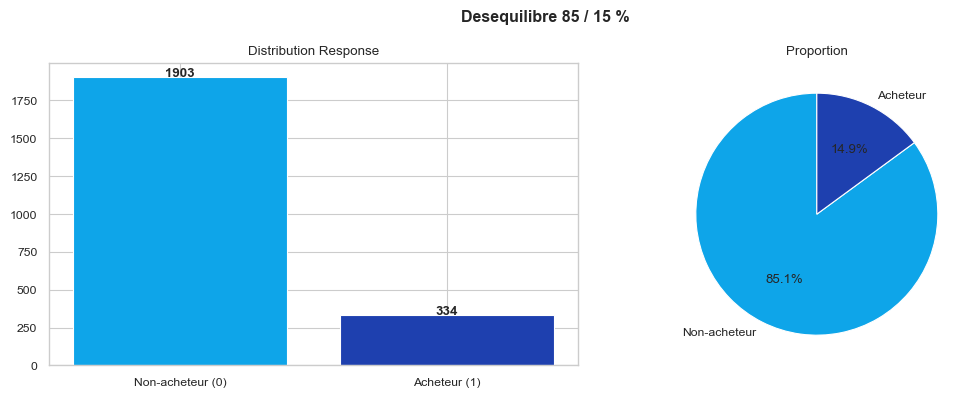

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['Response'].value_counts()
axes[0].bar(['Non-acheteur (0)','Acheteur (1)'], counts.values, color=['#0ea5e9','#1e40af'])
axes[0].set_title('Distribution Response')
for i,v in enumerate(counts.values): axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['Non-acheteur','Acheteur'],
            colors=['#0ea5e9','#1e40af'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion')
plt.suptitle('Desequilibre 85 / 15 %', fontweight='bold')
plt.tight_layout(); plt.show()

## Variables clés par classe

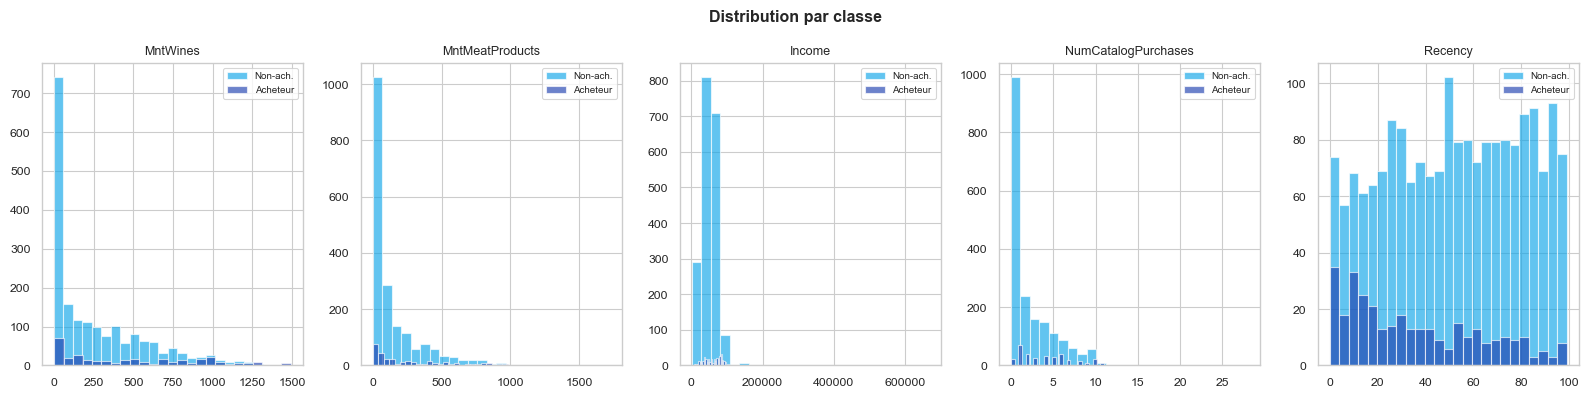

In [3]:
key_cols = ['MntWines','MntMeatProducts','Income','NumCatalogPurchases','Recency']
fig, axes = plt.subplots(1, len(key_cols), figsize=(16, 4))
for ax, col in zip(axes, key_cols):
    for resp, color, label in [(0,'#0ea5e9','Non-ach.'),(1,'#1e40af','Acheteur')]:
        ax.hist(df[df.Response==resp][col], bins=25, alpha=0.65, color=color, label=label)
    ax.set_title(col, fontsize=9); ax.legend(fontsize=7)
plt.suptitle('Distribution par classe', fontweight='bold')
plt.tight_layout(); plt.show()

## Matrice de corrélation Spearman

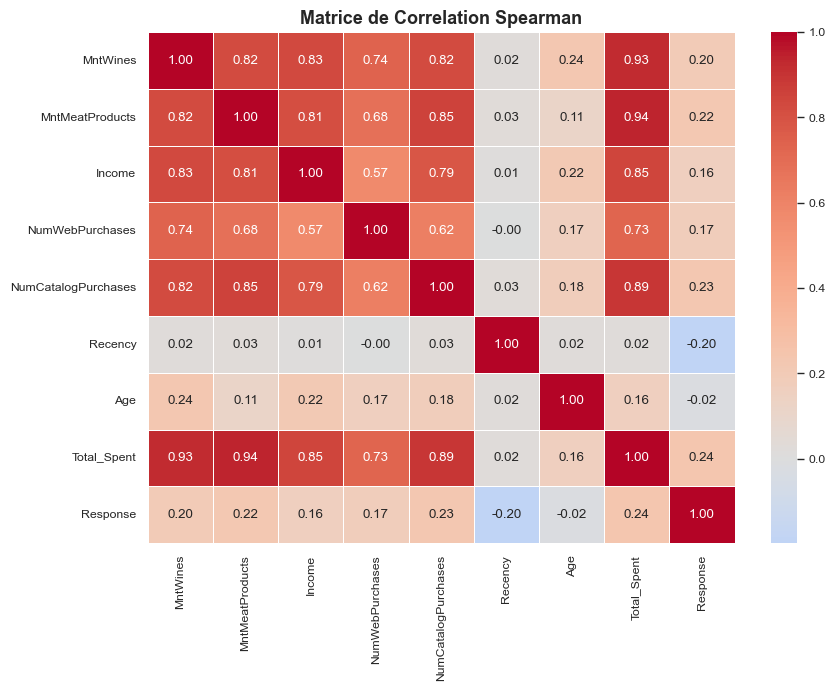

In [4]:
num_cols = ['MntWines','MntMeatProducts','Income','NumWebPurchases',
            'NumCatalogPurchases','Recency','Age','Total_Spent','Response']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Matrice de Correlation Spearman', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('c:/Users/ahoudzi/apti/aptispace-datascience-projet/report/assets/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## PCA 2D

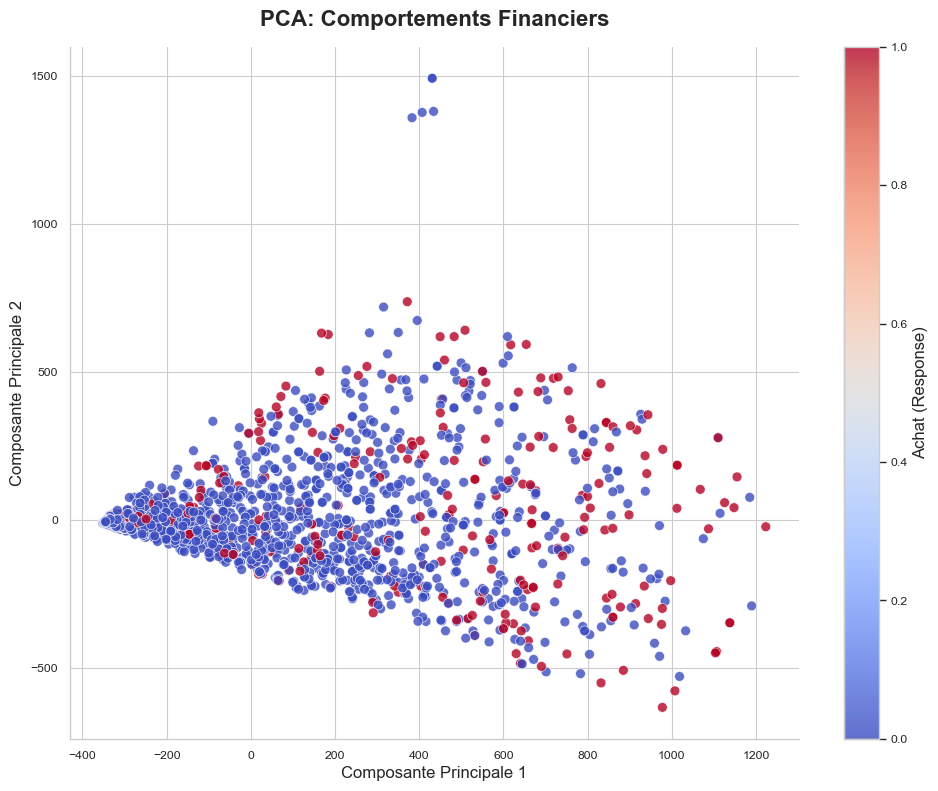

In [5]:
uv.plot_pca_projection(df)
plt.show()

## 5 Insights Cles

In [6]:
ratio_wines = df[df.Response==1]['MntWines'].mean() / df[df.Response==0]['MntWines'].mean()
q4 = df[df.Income > df.Income.quantile(0.75)]['Response'].mean()
q1 = df[df.Income < df.Income.quantile(0.25)]['Response'].mean()
multi = df[df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1)>=2]['Response'].mean()
spw   = (df.Response==0).sum()/(df.Response==1).sum()
print(f'1. MntWines : acheteurs depensent {ratio_wines:.1f}x plus')
print(f'2. Revenu Q4 : {q4:.0%} vs Q1 : {q1:.0%}')
print(f'3. >=2 campagnes -> {multi:.0%} de conversion')
print(f'4. Desequilibre -> scale_pos_weight = {spw:.1f}')
print(f'5. Kidhome/Teenhome : correlation negative avec Response')

1. MntWines : acheteurs depensent 1.9x plus
2. Revenu Q4 : 27% vs Q1 : 10%
3. >=2 campagnes -> 63% de conversion
4. Desequilibre -> scale_pos_weight = 5.7
5. Kidhome/Teenhome : correlation negative avec Response
